# 🔤 Tokenization Explorer: Understanding How LLMs Read Text

**Estimated Time:** 8-10 minutes

---

## What is Tokenization?

**Tokenization** is the process of breaking down text into smaller units called **tokens**. Think of it as teaching a computer how to "read" text.

### Why Does This Matter?

1. **LLMs don't read characters** - They read tokens (which can be parts of words, whole words, or even punctuation)
2. **Cost implications** - API costs are based on token count, not character count
3. **Context limits** - Models have maximum token limits (e.g., GPT-4 has 8K, 32K, or 128K token limits)
4. **Language efficiency** - Different languages require different numbers of tokens for the same meaning

### Key Concepts:

- A **token** ≈ 0.75 words in English (roughly 4 characters)
- Different tokenizers split text differently
- Common words are often single tokens: `"hello"` → `[hello]`
- Uncommon words get split: `"tokenization"` → `[token, ization]`
- Non-English text often requires more tokens

---

## 📦 Setup: Installing Required Libraries

In [ ]:
# Import dependencies
import tiktoken
from transformers import GPT2TokenizerFast, AutoTokenizer
import matplotlib.pyplot as plt

/home/finley/Work/RDS/CfRR/intro_to_llms/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## Part 1: Basic Tokenization

Let's start by seeing how a simple sentence is tokenized.

In [3]:
# Load OpenAI's GPT-4 tokenizer
tokenizer = tiktoken.get_encoding("cl100k_base")  # Used by GPT-4 and GPT-3.5-turbo

# Enter a sentence you wish to tokenize
text = "The quick brown fox jumps over the lazy dog."

# Tokenize
tokens = tokenizer.encode(text)
token_strings = [tokenizer.decode([token]) for token in tokens]

print(f"Original text: {text}")
print(f"Tokens: {tokens}")
print(f"Token strings: {token_strings}")

Original text: The quick brown fox jumps over the lazy dog.
Tokens: [791, 4062, 14198, 39935, 35308, 927, 279, 16053, 5679, 13]
Token strings: ['The', ' quick', ' brown', ' fox', ' jumps', ' over', ' the', ' lazy', ' dog', '.']


### 💡 Observation

Notice how:
- Each word is typically one token
- Punctuation marks are separate tokens
- Spaces are included with some tokens

---

## 🔄 Part 2: Comparing Different Tokenizers

Different models use different tokenizers. Let's see how the same text is tokenized differently!

In [4]:
# Sample text
sample_text = "Artificial intelligence is transforming technology."

# Initialize different tokenizers
# gpt4_enc = tiktoken.get_encoding("cl100k_base")  # GPT-4
# gpt2_tok = GPT2TokenizerFast.from_pretrained("gpt2")

gpt2_tok   = AutoTokenizer.from_pretrained("gpt2")
bert_tok   = AutoTokenizer.from_pretrained("bert-base-uncased")
t5_tok     = AutoTokenizer.from_pretrained("t5-small")
deep_tok  = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-R1-Distill-Llama-8B")

# Tokenize with each
gpt2_tokens = gpt2_tok.encode(sample_text, add_special_tokens=False)
bert_tokens = bert_tok.encode(sample_text, add_special_tokens=False)
t5_tokens = t5_tok.encode(sample_text, add_special_tokens=False)
deep_tokens = deep_tok.encode(sample_text, add_special_tokens=False)

print(gpt2_tokens)
print(bert_tokens)
print(t5_tokens)
print(deep_tokens)

print(gpt2_tok.decode(gpt2_tokens))
print(bert_tok.decode(bert_tokens))
print(t5_tok.decode(t5_tokens))
print(deep_tok.decode(deep_tokens))

[8001, 9542, 4430, 318, 25449, 3037, 13]
[7976, 4454, 2003, 17903, 2974, 1012]
[24714, 6123, 19, 3, 21139, 748, 5]
[9470, 16895, 93375, 3843, 598, 55857, 59342, 13]
Artificial intelligence is transforming technology.
artificial intelligence is transforming technology.
Artificial intelligence is transforming technology.
Artificialintelligenceistransformingtechnology.


In [5]:
print(gpt2_tok.decode(gpt2_tokens))
print(bert_tok.decode(gpt2_tokens))

Artificial intelligence is transforming technology.
revised luxuryah [unused313] truncated interest [unused12]


### 💡 Key Takeaway

Different models use different tokenization strategies:
- **GPT-4** (cl100k_base) - More efficient, larger vocabulary
- **GPT-2** - Older, smaller vocabulary
- **Llama-2** - Optimized for different use cases

This is why token counts can vary when using different models!

---

## 🌍 Part 3: Multilingual Tokenization

One of the most important aspects of tokenization: **language efficiency**. Let's see how different languages are tokenized.

In [6]:
# Same meaning in different languages
texts = {
    "English": "Hello, how are you?",
    "Spanish": "Hola, ¿cómo estás?",
    "French": "Bonjour, comment allez-vous?",
    "German": "Hallo, wie geht es dir?",
    "Japanese": "こんにちは、お元気ですか？",
    "Arabic": "مرحبا، كيف حالك؟",
    "Chinese": "你好，你好吗？",
    "Hindi": "नमस्ते, आप कैसे हैं?",
    "Emoji": "👋 🤔 😊 ❤️ 🎉"
}

# Tokenize each
encoding = tiktoken.get_encoding("cl100k_base")

results = []
for lang, text in texts.items():
    tokens = encoding.encode(text)
    print(lang, "\t", tokens)

English 	 [9906, 11, 1268, 527, 499, 30]
Spanish 	 [69112, 11, 29386, 66, 72561, 1826, 7206, 30]
French 	 [82681, 11, 4068, 12584, 89, 45325, 30]
German 	 [79178, 11, 13672, 40364, 1560, 5534, 30]
Japanese 	 [90115, 5486, 33334, 24186, 95221, 38641, 32149, 11571]
Arabic 	 [10386, 11318, 30925, 22071, 5821, 69885, 88041, 14900, 21604, 69338, 32482, 32173, 148, 253]
Chinese 	 [57668, 53901, 3922, 57668, 53901, 7305, 245, 11571]
Hindi 	 [61196, 88344, 79468, 31584, 97, 35470, 11, 15272, 228, 87262, 48909, 12906, 230, 79468, 35470, 85410, 12906, 230, 73414, 30]
Emoji 	 [9468, 239, 233, 11410, 97, 242, 27623, 232, 71570, 31643, 11410, 236, 231]


### 💡 Critical Insight

**Language bias in tokenization:**
- English is most efficient (fewest tokens per meaning)
- Non-Latin scripts (Japanese, Arabic, Hindi) require **2-4x more tokens**
- This means:
  - 💰 **Higher API costs** for non-English users
  - ⏱️ **Slower processing** times
  - 📊 **Reduced context window** (fewer words fit in the same token limit)

This is an important consideration for building multilingual applications!

---

## 💻 Part 4: Code vs Natural Language Tokenization

How does tokenization handle code compared to natural language?

In [7]:
# OpenAI pricing (as of 2024 - check current pricing)
pricing = {
    "GPT-4 Turbo": {"input": 0.01, "output": 0.03},  # per 1K tokens
    "GPT-3.5 Turbo": {"input": 0.0005, "output": 0.0015},
}

# Example: A chatbot conversation
user_message = "Can you explain quantum computing in simple terms?"
assistant_response = """Quantum computing uses quantum mechanics principles to process information. 
Unlike classical computers that use bits (0 or 1), quantum computers use quantum bits or 'qubits' 
that can exist in multiple states simultaneously through superposition. This allows them to perform 
certain calculations much faster than classical computers. Key concepts include superposition, 
entanglement, and interference. Applications include cryptography, drug discovery, and optimization problems."""

encoding = tiktoken.get_encoding("cl100k_base")
input_tokens = len(encoding.encode(user_message))
output_tokens = len(encoding.encode(assistant_response))

print("Single Conversation:")
print("="*60)
print(f"User message: {input_tokens} tokens")
print(f"Assistant response: {output_tokens} tokens")
print(f"Total: {input_tokens + output_tokens} tokens\n")

for model, prices in pricing.items():
    input_cost = (input_tokens / 1000) * prices["input"]
    output_cost = (output_tokens / 1000) * prices["output"]
    total_cost = input_cost + output_cost
    
    print(f"{model}:")
    print(f"  Cost per conversation: ${total_cost:.6f}")
    print(f"  Cost for 1,000 conversations: ${total_cost * 1000:.2f}")
    print(f"  Cost for 1,000,000 conversations: ${total_cost * 1000000:.2f}")
    print()

Single Conversation:
User message: 9 tokens
Assistant response: 86 tokens
Total: 95 tokens

GPT-4 Turbo:
  Cost per conversation: $0.002670
  Cost for 1,000 conversations: $2.67
  Cost for 1,000,000 conversations: $2670.00

GPT-3.5 Turbo:
  Cost per conversation: $0.000133
  Cost for 1,000 conversations: $0.13
  Cost for 1,000,000 conversations: $133.50



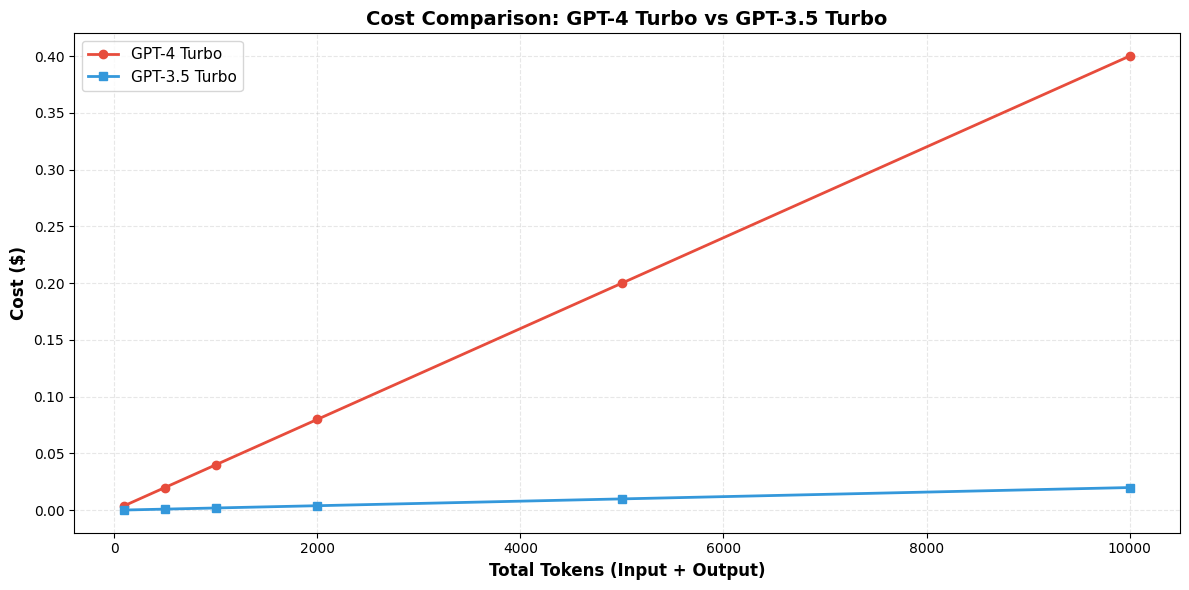


💡 Key Insight: Understanding token counts helps you:
   • Choose the right model for your budget
   • Optimize prompts to reduce costs
   • Predict and control API expenses


In [8]:
# Compare costs for different input sizes
import numpy as np

# Simulate different conversation lengths
conversation_lengths = [100, 500, 1000, 2000, 5000, 10000]  # in tokens
gpt4_costs = [(tokens / 1000) * (pricing["GPT-4 Turbo"]["input"] + pricing["GPT-4 Turbo"]["output"]) 
              for tokens in conversation_lengths]
gpt35_costs = [(tokens / 1000) * (pricing["GPT-3.5 Turbo"]["input"] + pricing["GPT-3.5 Turbo"]["output"]) 
               for tokens in conversation_lengths]

plt.figure(figsize=(12, 6))
plt.plot(conversation_lengths, gpt4_costs, marker='o', linewidth=2, label='GPT-4 Turbo', color='#e74c3c')
plt.plot(conversation_lengths, gpt35_costs, marker='s', linewidth=2, label='GPT-3.5 Turbo', color='#3498db')
plt.xlabel('Total Tokens (Input + Output)', fontsize=12, fontweight='bold')
plt.ylabel('Cost ($)', fontsize=12, fontweight='bold')
plt.title('Cost Comparison: GPT-4 Turbo vs GPT-3.5 Turbo', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n💡 Key Insight: Understanding token counts helps you:")
print("   • Choose the right model for your budget")
print("   • Optimize prompts to reduce costs")
print("   • Predict and control API expenses")

---

## 🎯 Part 6: Hands-On Exercises

Now it's your turn! Try these exercises to deepen your understanding.

### Exercise 1: Analyze Your Own Text

**Task:** Take a paragraph from your research, documentation, or a recent email and analyze its tokenization.

**Questions to answer:**
1. How many tokens does it use?
2. What's the character-to-token ratio?
3. Which words get split into multiple tokens?
4. How much would it cost to process this text 1000 times with GPT-4?

In [9]:
# Exercise 1: Your code here
encoding = tiktoken.get_encoding("cl100k_base")

my_text = """[Paste your text here]"""

# TODO: Tokenize and analyze
# Hint: Use encoding.encode() and check individual tokens


### Exercise 2: Optimize a Prompt

**Task:** You have this verbose prompt. Can you reduce the token count while keeping the same meaning?

Original prompt:
```
"Please provide me with a comprehensive and detailed explanation regarding 
the various different ways in which machine learning algorithms can be 
utilized and applied in the field of healthcare and medical diagnostics."
```

**Goal:** Reduce tokens by at least 30% without losing meaning.

In [10]:
# Exercise 2: Your code here
encoding = tiktoken.get_encoding("cl100k_base")

original_prompt = """Please provide me with a comprehensive and detailed explanation 
regarding the various different ways in which machine learning algorithms can be 
utilized and applied in the field of healthcare and medical diagnostics."""

optimized_prompt = """[Your optimized version here]"""

# Compare token counts
original_tokens = len(encoding.encode(original_prompt))
optimized_tokens = len(encoding.encode(optimized_prompt))

print(f"Original: {original_tokens} tokens")
print(f"Optimized: {optimized_tokens} tokens")
print(f"Reduction: {((original_tokens - optimized_tokens) / original_tokens * 100):.1f}%")


Original: 37 tokens
Optimized: 6 tokens
Reduction: 83.8%


### Exercise 4: Context Window Challenge

**Scenario:** You're building a chatbot with a 4,096 token context limit. You need to include:
- A system prompt (instructions to the AI)
- Conversation history
- User's current message
- Room for the AI's response

**Task:** Design a system that manages this context window effectively.

Given the texts below, calculate:
1. How many tokens each component uses
2. How many previous messages you can include
3. How many tokens remain for the AI's response

In [11]:
# Exercise 4: Your code here
encoding = tiktoken.get_encoding("cl100k_base")

CONTEXT_LIMIT = 4096

system_prompt = """You are a helpful AI assistant specialized in explaining 
complex topics in simple terms. Be concise but thorough."""

conversation_history = [
    "User: What is Python?",
    "AI: Python is a high-level programming language known for its simplicity...",
    "User: How do I install it?",
    "AI: You can download Python from python.org...",
    "User: What are the best Python IDEs?",
    "AI: Popular IDEs include PyCharm, VS Code, and Jupyter Notebooks...",
    "User: How do I create a virtual environment?",
    "AI: You can use 'python -m venv myenv' to create a virtual environment...",
    "User: What's the difference between lists and tuples?",
    "AI: Lists are mutable and use square brackets, while tuples are immutable...",
]

current_user_message = "Can you explain list comprehensions?"

# TODO: Calculate token usage and available space


In [12]:

# ============================================================================
# SOLUTION (commented out - students should try first!)
# ============================================================================

# Step 1: Count tokens for each component
system_tokens = len(encoding.encode(system_prompt))
current_msg_tokens = len(encoding.encode(current_user_message))

print(f"📊 Token Budget Analysis")
print(f"{'='*60}")
print(f"Context Limit: {CONTEXT_LIMIT:,} tokens\n")

print(f"🔧 Fixed Components:")
print(f"  System Prompt: {system_tokens} tokens")
print(f"  Current Message: {current_msg_tokens} tokens")

# Step 2: Reserve tokens for AI response (rule of thumb: ~500-1000 tokens)
RESPONSE_BUFFER = 800
print(f"  Response Buffer: {RESPONSE_BUFFER} tokens")

# Step 3: Calculate available tokens for conversation history
fixed_tokens = system_tokens + current_msg_tokens + RESPONSE_BUFFER
available_for_history = CONTEXT_LIMIT - fixed_tokens

print(f"\n📝 Available for History: {available_for_history} tokens")
print(f"{'='*60}\n")

# Step 4: Count tokens for each message in history and fit what we can
history_tokens = []
for msg in conversation_history:
    tokens = len(encoding.encode(msg))
    history_tokens.append((msg, tokens))

# Start from most recent messages and work backwards
included_messages = []
total_history_tokens = 0

for msg, tokens in reversed(history_tokens):
    if total_history_tokens + tokens <= available_for_history:
        included_messages.insert(0, (msg, tokens))
        total_history_tokens += tokens
    else:
        break

# Step 5: Display results
print(f"✅ Messages to Include (most recent {len(included_messages)}/{len(conversation_history)}):")
for i, (msg, tokens) in enumerate(included_messages, 1):
    preview = msg[:50] + "..." if len(msg) > 50 else msg
    print(f"  {i}. [{tokens:3d} tokens] {preview}")

print(f"\n🔢 Final Token Breakdown:")
print(f"  System Prompt:        {system_tokens:4d} tokens")
print(f"  Conversation History: {total_history_tokens:4d} tokens")
print(f"  Current Message:      {current_msg_tokens:4d} tokens")
print(f"  Response Buffer:      {RESPONSE_BUFFER:4d} tokens")
print(f"  {'-'*40}")
print(f"  TOTAL USED:           {system_tokens + total_history_tokens + current_msg_tokens + RESPONSE_BUFFER:4d} tokens")
print(f"  Remaining:            {CONTEXT_LIMIT - (system_tokens + total_history_tokens + current_msg_tokens + RESPONSE_BUFFER):4d} tokens")

# Bonus: Show what happens if we exceed the limit
all_history_tokens = sum(t for _, t in history_tokens)
print(f"\n⚠️  If we included ALL history: {all_history_tokens} tokens")
print(f"   This would exceed limit by: {max(0, system_tokens + all_history_tokens + current_msg_tokens + RESPONSE_BUFFER - CONTEXT_LIMIT)} tokens")

# Step 6: Create the final prompt that would be sent to the API
print(f"\n🚀 Final Prompt Structure:")
print(f"   [System: {system_tokens} tokens]")
for i, (msg, tokens) in enumerate(included_messages):
    print(f"   [History {i+1}: {tokens} tokens]")
print(f"   [User: {current_msg_tokens} tokens]")
print(f"   [Reserved for AI Response: {RESPONSE_BUFFER} tokens]")

📊 Token Budget Analysis
Context Limit: 4,096 tokens

🔧 Fixed Components:
  System Prompt: 21 tokens
  Current Message: 7 tokens
  Response Buffer: 800 tokens

📝 Available for History: 3268 tokens

✅ Messages to Include (most recent 10/10):
  1. [  6 tokens] User: What is Python?
  2. [ 14 tokens] AI: Python is a high-level programming language kn...
  3. [  8 tokens] User: How do I install it?
  4. [ 10 tokens] AI: You can download Python from python.org...
  5. [ 10 tokens] User: What are the best Python IDEs?
  6. [ 19 tokens] AI: Popular IDEs include PyCharm, VS Code, and Jup...
  7. [ 10 tokens] User: How do I create a virtual environment?
  8. [ 20 tokens] AI: You can use 'python -m venv myenv' to create a...
  9. [ 11 tokens] User: What's the difference between lists and tupl...
  10. [ 15 tokens] AI: Lists are mutable and use square brackets, whi...

🔢 Final Token Breakdown:
  System Prompt:          21 tokens
  Conversation History:  123 tokens
  Current Message:         7 toke

---

## 🎓 Key Takeaways

By now, you should understand:

✅ **What tokenization is** and why LLMs need it  
✅ **How different tokenizers work** and produce different results  
✅ **Language efficiency matters** - English is privileged in current tokenizers  
✅ **Code uses more tokens** than natural language  
✅ **Token counts directly impact costs** - optimize your prompts!  
✅ **Context windows are measured in tokens** - manage them carefully  

### 🔧 Practical Applications:

1. **Cost Optimization:** Shorter, clearer prompts = lower costs
2. **Multilingual Apps:** Budget more for non-English languages
3. **Context Management:** Track tokens to avoid hitting limits
4. **Model Selection:** Consider tokenizer efficiency when choosing models

### 📚 Further Exploration:

- [OpenAI Tokenizer Tool](https://platform.openai.com/tokenizer) - Interactive web tool
- [tiktoken GitHub](https://github.com/openai/tiktoken) - Source code and documentation
- [Hugging Face Tokenizers](https://huggingface.co/docs/tokenizers/) - Learn about other tokenizers

---

## 🎉 Congratulations!

You've completed the Tokenization Explorer notebook. You now have a fundamental understanding of how LLMs process text at the token level.

**Next Steps:** Apply this knowledge when crafting prompts, building applications, and optimizing costs!